In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("wine-quality.csv")
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,type
0,7.3,0.51,0.29,11.30,0.034,61.0,224.0,0.99683,3.14,0.56,9.5,6,0
1,9.9,0.40,0.53,6.70,0.097,6.0,19.0,0.99860,3.27,0.82,11.7,7,1
2,6.7,0.24,0.26,12.60,0.053,44.0,182.0,0.99802,3.42,0.42,9.7,5,0
3,5.6,0.18,0.58,1.25,0.034,29.0,129.0,0.98984,3.51,0.60,12.0,7,0
4,8.2,0.18,0.31,11.80,0.039,96.0,249.0,0.99760,3.07,0.52,9.5,6,0


In [3]:
df.shape

(6497, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [5]:
df.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,type
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.246114
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.430779
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,0.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,0.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,0.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


In [6]:
df.isnull().sum()

fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(1177)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.reset_index(drop=True, inplace=True)

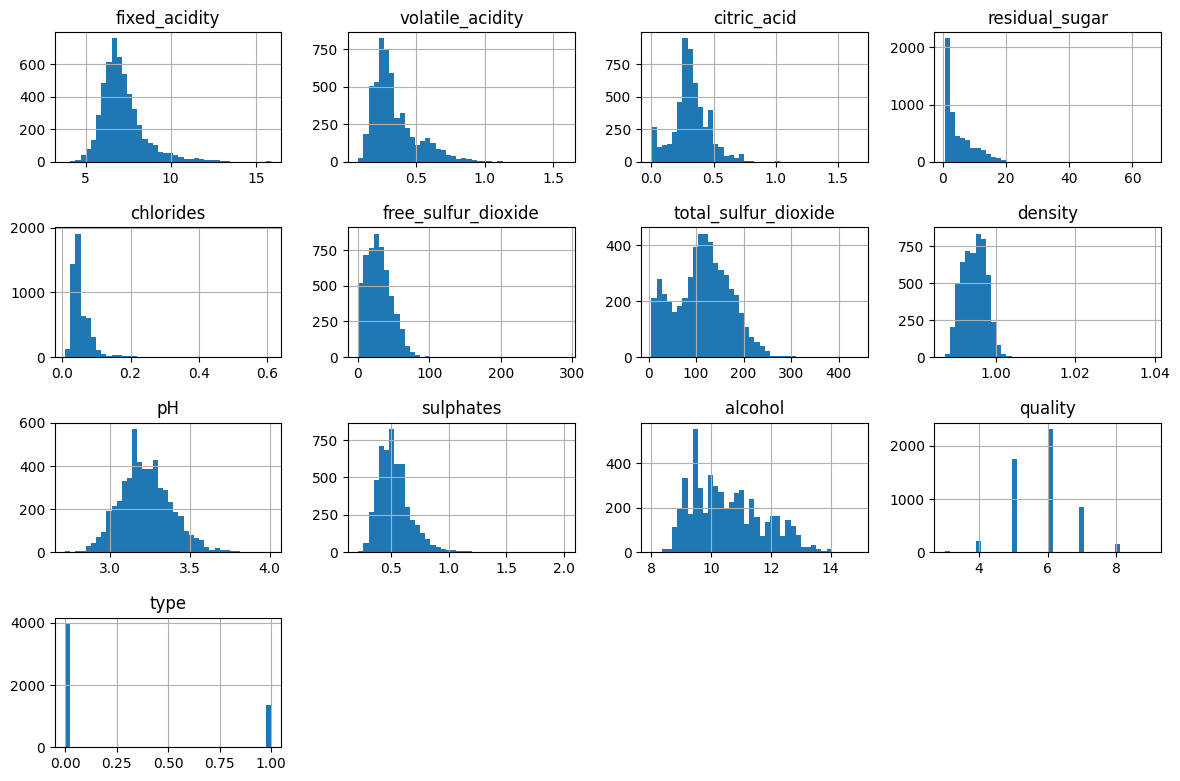

In [10]:
df.hist(bins=40, figsize=(12, 8))
plt.tight_layout(pad=1.4)
plt.show()

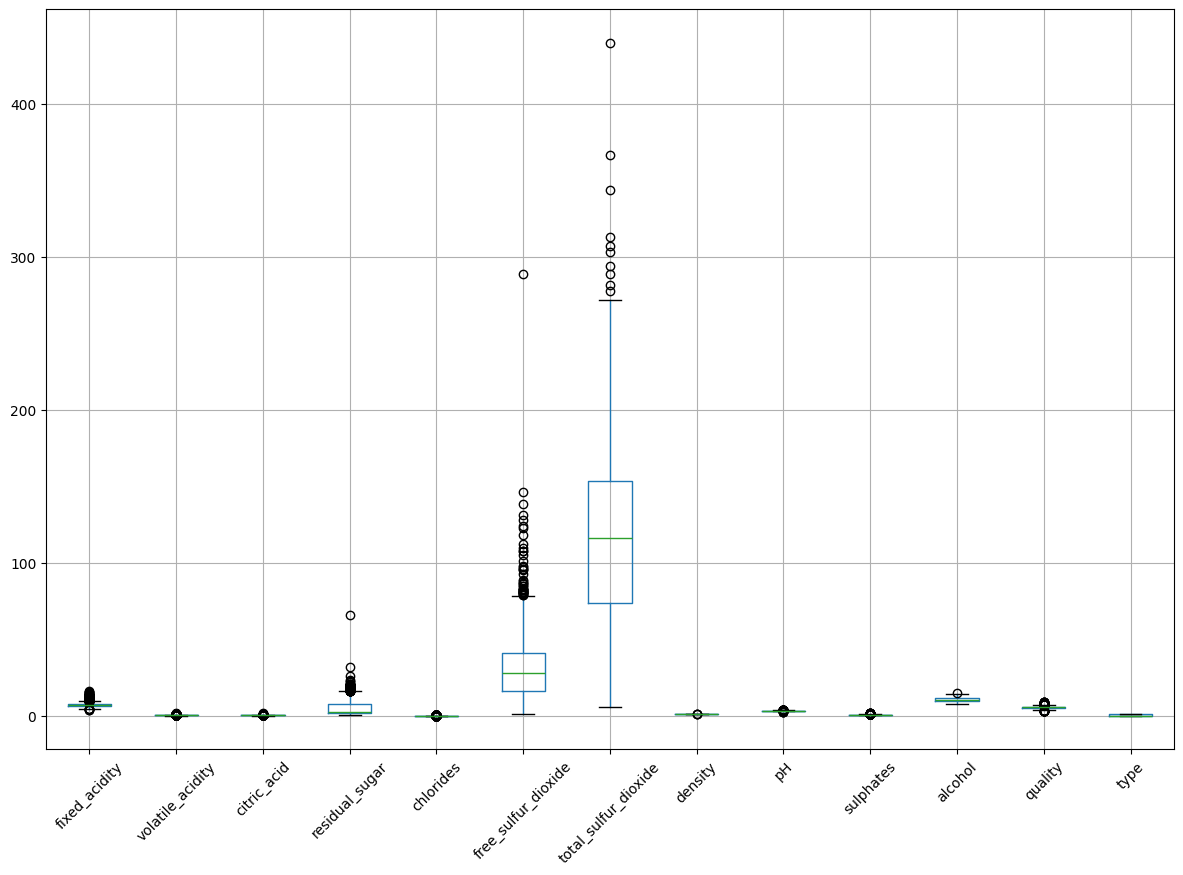

In [11]:
df.boxplot(figsize=(12, 8))
plt.tight_layout(pad=1.3)
plt.xticks(rotation=45)
plt.show()

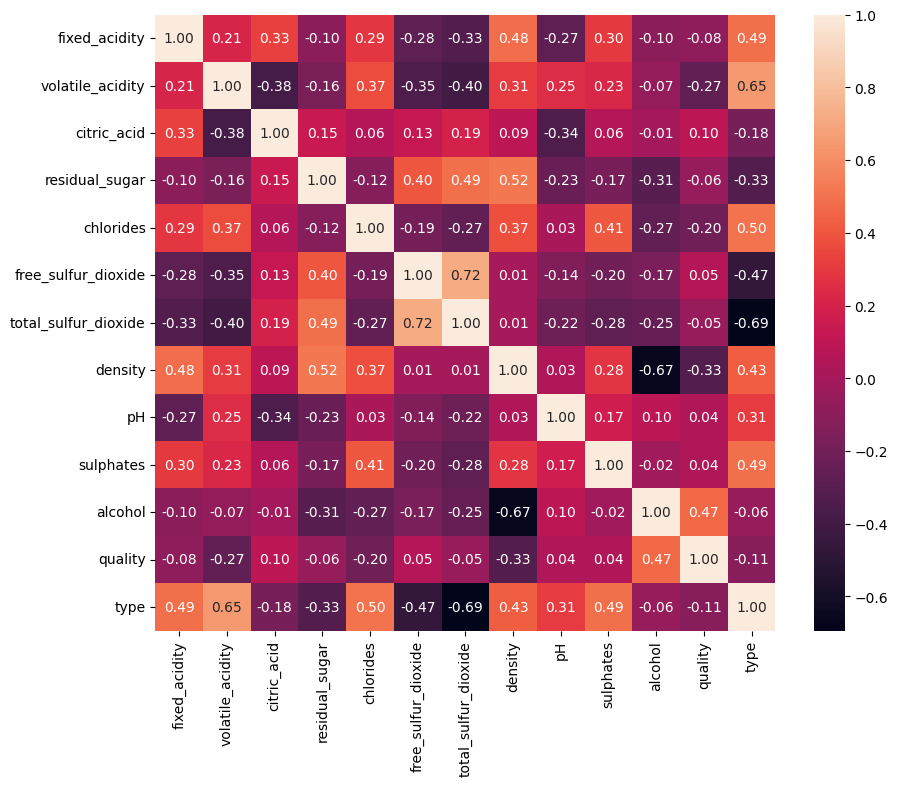

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f')
plt.show()

In [ ]:
cols = "volatile_acidity", "citric_acid", "chlorides", "density", "alcohol", "type"

In [38]:
from sklearn.model_selection import train_test_split
x = df[["volatile_acidity", "citric_acid", "chlorides", "density", "alcohol", "type"]]

x_train, x_val, y_train, y_val = train_test_split(
      x,
      df['quality'],
      test_size=0.3
)

In [39]:
def remove_outliers_iqr(df, columns):
    bounds = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        bounds[col] = (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
    return bounds

In [40]:
# outlier_col = ['total_sulfur_dioxide', 'free_sulfur_dioxide', 'residual_sugar']

# bounds = remove_outliers_iqr(x_train, outlier_col)

# for col, (lower, upper) in bounds.items():
#       mask = (x_train[col] >= lower) & (x_train[col] <= upper)
#       x_train = x_train[mask]
#       y_train = y_train[mask]

# for col, (lower, upper) in bounds.items():
#     x_val[col] = x_val[col].clip(lower, upper)

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scale = scaler.fit_transform(x_train)
x_val_scale = scaler.transform(x_val)

In [42]:
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge

In [44]:
import mlflow
from wineModel.utils.mlflow_config import configure_mlflow

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def eval_model(y_test, y_pred):
      mae = mean_absolute_error(y_test, y_pred)
      mse = mean_squared_error(y_test, y_pred)
      r2 = r2_score(y_test, y_pred)
      return mae, mse, r2

configure_mlflow(experiment_name="Experiment:3")

with mlflow.start_run(run_name="LR-Model"):
      model_lr = LinearRegression()
      model_lr.fit(x_train_scale, y_train)

      y_pred_lr = model_lr.predict(x_val_scale)
      mae, mse, r2 = eval_model(y_val, y_pred_lr)
      
      mlflow.log_metrics({
            "MAE": mae,
            "MSE": mse,
            'r2': r2
      })

      mlflow.sklearn.log_model(model_lr, "LR-Model")  
      mlflow.end_run()


with mlflow.start_run(run_name="EL-Model"):
      model_el = ElasticNet()
      model_el.fit(x_train_scale, y_train)

      y_pred_el = model_el.predict(x_val_scale)
      mae, mse, r2 = eval_model(y_val, y_pred_el)
      
      mlflow.log_metrics({
            "MAE": mae,
            "MSE": mse,
            'r2': r2
      })

      mlflow.sklearn.log_model(model_el, "EL-Model")
      mlflow.end_run()


with mlflow.start_run(run_name="RF-Model"):
      model_rf = RandomForestRegressor()
      model_rf.fit(x_train_scale, y_train)

      y_pred_rf = model_lr.predict(x_val_scale)
      mae, mse, r2 = eval_model(y_val, y_pred_rf)
      
      mlflow.log_metrics({
            "MAE": mae,
            "MSE": mse,
            'r2': r2
      })

      mlflow.sklearn.log_model(model_rf, "RF-Model")
      mlflow.end_run()

with mlflow.start_run(run_name="SVR-Model"):
      model_svm = SVR()
      model_svm.fit(x_train_scale, y_train)

      y_pred_svm = model_svm.predict(x_val_scale)
      mae, mse, r2 = eval_model(y_val, y_pred_svm)
      
      mlflow.log_metrics({
            "MAE": mae,
            "MSE": mse,
            'r2': r2
      })

      mlflow.sklearn.log_model(model_svm, "SVR-Model")
      mlflow.end_run()

with mlflow.start_run(run_name="Ridge-Model"):
      model_r = Ridge(alpha=0.1)
      model_r.fit(x_train_scale, y_train)

      y_pred_r = model_lr.predict(x_val_scale)
      mae, mse, r2 = eval_model(y_val, y_pred_r)
      
      mlflow.log_metrics({
            "MAE": mae,
            "MSE": mse,
            'r2': r2
      })

      mlflow.sklearn.log_model(model_rf, "RF-Model")
      mlflow.end_run()

2026/03/22 16:19:15 INFO mlflow.tracking.fluent: Experiment with name 'Experiment:3' does not exist. Creating a new experiment.


Mlflow -> Dagshub | Experiment: Experiment:3


2026/03/22 16:19:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 16:19:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LR-Model at: https://dagshub.com/HimmatMagar/Wine-Quality-Prediction.mlflow/#/experiments/6/runs/880e0b80487143d1b4c791e06bf55c6e
🧪 View experiment at: https://dagshub.com/HimmatMagar/Wine-Quality-Prediction.mlflow/#/experiments/6


2026/03/22 16:19:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 16:19:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

🏃 View run RF-Model at: https://dagshub.com/HimmatMagar/Wine-Quality-Prediction.mlflow/#/experiments/6/runs/e140c711d9e64b51b6a32c5520ccd83d
🧪 View experiment at: https://dagshub.com/HimmatMagar/Wine-Quality-Prediction.mlflow/#/experiments/6


2026/03/22 16:20:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 16:20:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run SVR-Model at: https://dagshub.com/HimmatMagar/Wine-Quality-Prediction.mlflow/#/experiments/6/runs/790336dcbdd74df89298eda10241e2f3
🧪 View experiment at: https://dagshub.com/HimmatMagar/Wine-Quality-Prediction.mlflow/#/experiments/6


2026/03/22 16:20:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 16:20:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Ridge-Model at: https://dagshub.com/HimmatMagar/Wine-Quality-Prediction.mlflow/#/experiments/6/runs/c65d6eb18b0d4fcc861405b3af6b6bff
🧪 View experiment at: https://dagshub.com/HimmatMagar/Wine-Quality-Prediction.mlflow/#/experiments/6


In [35]:
from sklearn.ensemble import GradientBoostingRegressor

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def eval_model(y_test, y_pred):
      mae = mean_absolute_error(y_test, y_pred)
      mse = mean_squared_error(y_test, y_pred)
      r2 = r2_score(y_test, y_pred)
      return mae, mse, r2

configure_mlflow(experiment_name="Experiment:2")

with mlflow.start_run(run_name="GBR"):
      model_gbr = GradientBoostingRegressor()
      model_gbr.fit(x_train_scale, y_train)

      y_pred_gbr = model_lr.predict(x_val_scale)
      mae, mse, r2 = eval_model(y_val, y_pred_gbr)
      
      mlflow.log_metrics({
            "MAE": mae,
            "MSE": mse,
            'r2': r2
      })

      mlflow.sklearn.log_model(model_lr, "GBR-Model")  
      mlflow.end_run()

2026/03/22 16:14:41 INFO mlflow.tracking.fluent: Experiment with name 'Experiment:2' does not exist. Creating a new experiment.


Mlflow -> Dagshub | Experiment: Experiment:2


2026/03/22 16:14:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 16:14:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run GBR at: https://dagshub.com/HimmatMagar/Wine-Quality-Prediction.mlflow/#/experiments/5/runs/bbd956648eb642069c20669b4932baf2
🧪 View experiment at: https://dagshub.com/HimmatMagar/Wine-Quality-Prediction.mlflow/#/experiments/5
